# Momentum Strategy

Strategy that focuses on exploiting market herding behavior that represents the most significant price movements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from utils.read_prices import read_parquet
from utils.metrics import Metrics as m
import talib

In [2]:
df = read_parquet()
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615


In [3]:
init_investment = 1000

In [4]:
df["position"] = np.sign(df["log_returns"])

df["momentum_strat"] = df["position"].shift(1) * df["log_returns"]

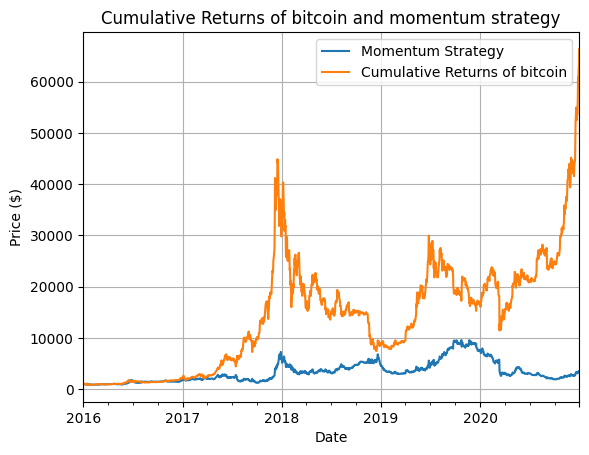

In [5]:
cum_returns = np.exp(df[["momentum_strat", "log_returns"]].cumsum())*init_investment
cum_returns.plot(kind="line")
plt.legend(["Momentum Strategy", "Cumulative Returns of bitcoin"])
plt.ylabel("Price ($)")
plt.title("Cumulative Returns of bitcoin and momentum strategy")
plt.grid(.4)
plt.show()

In [6]:
print(f"Terminal return of bitcoin: {m.terminal_return(df['log_returns'])*100:.2f}%")
print(f"Terminal return of momentum strategy: {m.terminal_return(df['momentum_strat'])*100:.2f}%\n")
print(f"Annualized returns of bitcoin: {m.annualized_return(df['returns'])*100:.2f}%")
print(f"Annualized returns of momentum strategy: {m.annualized_return(np.exp(df['momentum_strat']))*100:.2f}%")

Terminal return of bitcoin: 6540.27%
Terminal return of momentum strategy: 251.73%

Annualized returns of bitcoin: 131.33%
Annualized returns of momentum strategy: 28.58%


A rolling window can also be implemented to look at the last n-days of the price to gain a different momentum strategy.

In [7]:
df["position_weekly"] = np.sign(df["log_returns"].rolling(7).mean())

df["momentum_strat_weekly"] = df["position_weekly"].shift(1) * df["log_returns"]

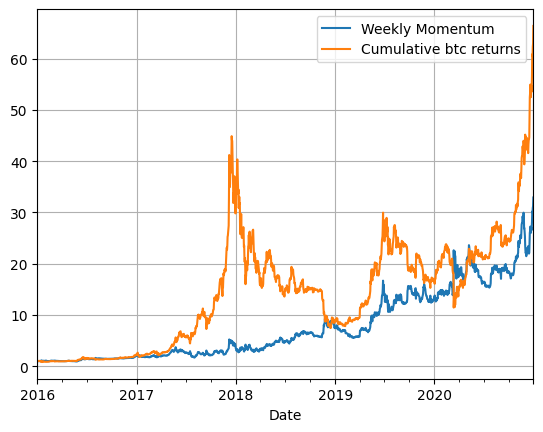

In [8]:
np.exp(df[["momentum_strat_weekly", "log_returns"]].cumsum()).plot(kind="line")
plt.legend(['Weekly Momentum', "Cumulative btc returns"])
plt.grid(.4)
plt.show()

In [9]:
print(f"Terminal return of bitcoin: {m.terminal_return(df['log_returns'])*100:.2f}%")
print(f"Terminal return of momentum strategy: {m.terminal_return(df['momentum_strat_weekly'])*100:.2f}%")

Terminal return of bitcoin: 6540.27%
Terminal return of momentum strategy: 3192.46%


In [10]:
31.92/2.51

12.717131474103587

We can see that by changing the window, the cumulative returns improve by over a factor of 12!

## Simulating different windows

Running a simple simulation of different windows, we can better our understanding of the returns in one single chart.

In [11]:
momentum_strategies = [df['log_returns']]

for i in [2,4,7,14,30]:
    close_sign = np.sign(df['log_returns'].rolling(i).mean())

    strat = df['log_returns'] * close_sign.shift(1)

    momentum_strategies.append(strat)

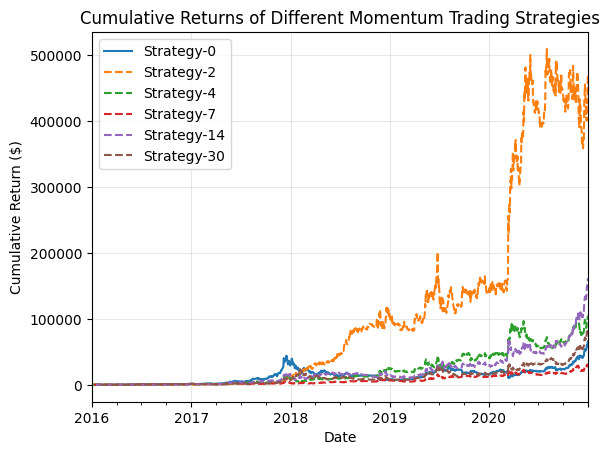

In [12]:
for strategy,\
    sma,\
    linestyle in zip(momentum_strategies,
                     [0,2,4,7,14,30],
                     ['-', '--', '--', '--', '--', '--', '--', '--']):
    returns = np.exp(strategy.cumsum())*init_investment
    returns.plot(kind='line', label=f"Strategy-{sma}", linestyle=linestyle)

plt.legend()
plt.title('Cumulative Returns of Different Momentum Trading Strategies')
plt.ylabel('Cumulative Return ($)')
plt.grid(alpha=.3)
plt.show()

In [13]:
df_ = df.copy()

df["sign"] = np.sign(df_['log_returns'].rolling(2).mean())

df["2-day-momentum-strat"] = df['log_returns'] * df["sign"].shift(1)

In [14]:
print(f"Terminal return of btc: {m.terminal_return(df['log_returns'])*100:.2f}%")
print(f"Terminal return of 2-day momentum strategy: {m.terminal_return(df['2-day-momentum-strat'])*100:.2f}%\n")
print(f"Annualized returns of bitcoin: {m.annualized_return(df['returns'])*100:.2f}%")
print(f"Annualized returns of momentum strategy: {m.annualized_return(np.exp(df['2-day-momentum-strat']))*100:.2f}%")

Terminal return of btc: 6540.27%
Terminal return of 2-day momentum strategy: 46792.13%

Annualized returns of bitcoin: 131.33%
Annualized returns of momentum strategy: 241.92%


## Backtest

In [15]:
from utils.backtest import MomentumBacktest

mombt = MomentumBacktest('BTC-USD',
                         '2021-01-01',
                         '2025-12-31',
                        #  trans_cost=0.0036,
                         amount=init_investment)
cret, cstrat = mombt.strategy(momentum=2)

cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(2697.52), np.float64(4930.79))

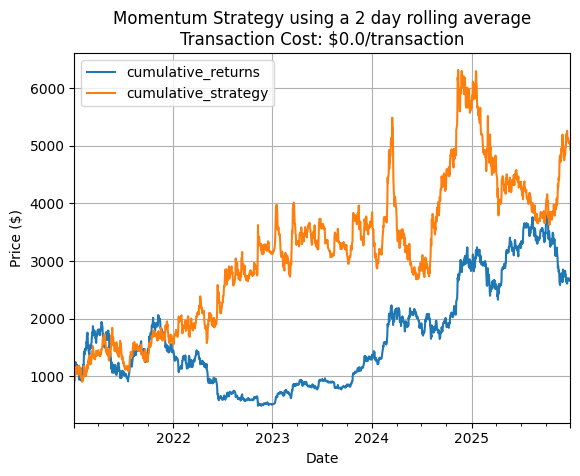

In [16]:
mombt.plot_strategy()

In [17]:
mombt.get_terminal_return(), mombt.get_drawdown()

/Users/smittyboop/Desktop/BTC Trading Strategies/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


((1.7, 3.93),
 (np.float64(-1.0005048325928618), np.float64(-1.0062609687776063)))

In [18]:
mombt_trans = MomentumBacktest('BTC-USD',
                         '2021-01-01',
                         '2025-12-31',
                         trans_cost=0.0036,
                         amount=init_investment)
cret_trans, cstrat_trans = mombt_trans.strategy(momentum=2)

cret_trans, cstrat_trans

[*********************100%***********************]  1 of 1 completed


(np.float64(2697.52), np.float64(4919.7))

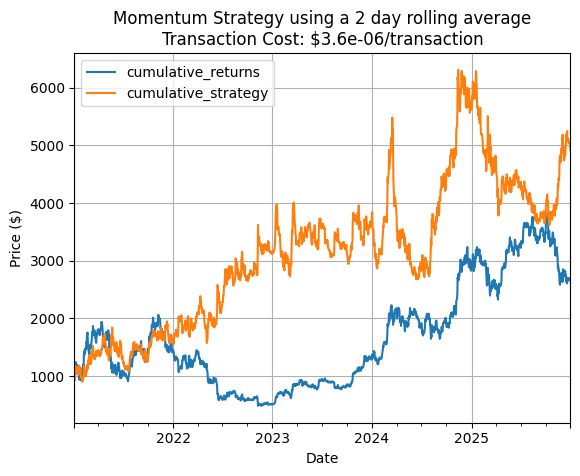

In [19]:
mombt_trans.plot_strategy()

In [20]:
mombt_trans.get_terminal_return(), mombt_trans.get_drawdown()

/Users/smittyboop/Desktop/BTC Trading Strategies/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


((1.7, 3.92),
 (np.float64(-1.0005048325928618), np.float64(-1.0062645462316793)))

In [21]:
mombt = MomentumBacktest('BTC-USD',
                         '2021-01-01',
                         '2025-12-31',
                         trans_cost=0.01,
                         amount=init_investment)
cret, cstrat = mombt.strategy(momentum=2)

cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(2697.52), np.float64(4900.06))

In [22]:
mombt.get_terminal_return(), mombt.get_drawdown()

/Users/smittyboop/Desktop/BTC Trading Strategies/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


((1.7, 3.9), (np.float64(-1.0005048325928618), np.float64(-inf)))